#### Redshift evolution

In [8]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt

from functions import *
unit = 'Mpc/h'

In [9]:
# find file corresponding to different redshifts
print(caesar.progen.z_to_snap(0))
print(caesar.progen.z_to_snap(0.5))
print(caesar.progen.z_to_snap(1)) 
print(caesar.progen.z_to_snap(1.5))
print(caesar.progen.z_to_snap(2))

(151, 0.0)
(125, 0.49043513253694404)
(105, 0.9926987517735022)
(90, 1.4966918832546874)
(78, 2.0246204101385272)


In [10]:
# define and load file
obj_0 = caesar.load('data/m50n512_151.hdf5')
obj_05 = caesar.load('data/m50n512_125.hdf5')
obj_1 = caesar.load('data/m50n512_105.hdf5')
obj_15 = caesar.load('data/m50n512_090.hdf5')
obj_2 = caesar.load('data/m50n512_078.hdf5')

yt : [INFO     ] 2023-11-24 15:17:46,955 Opening data/m50n512_151.hdf5
yt : [INFO     ] 2023-11-24 15:17:47,021 Found 58101 halos
yt : [INFO     ] 2023-11-24 15:17:47,036 Found 6922 galaxies
yt : [INFO     ] 2023-11-24 15:17:47,040 Opening data/m50n512_125.hdf5
yt : [INFO     ] 2023-11-24 15:17:47,076 Found 61977 halos
yt : [INFO     ] 2023-11-24 15:17:47,086 Found 5685 galaxies
yt : [INFO     ] 2023-11-24 15:17:47,089 Opening data/m50n512_105.hdf5
yt : [INFO     ] 2023-11-24 15:17:47,136 Found 65993 halos
yt : [INFO     ] 2023-11-24 15:17:47,148 Found 4931 galaxies
yt : [INFO     ] 2023-11-24 15:17:47,152 Opening data/m50n512_090.hdf5
yt : [INFO     ] 2023-11-24 15:17:47,193 Found 68131 halos
yt : [INFO     ] 2023-11-24 15:17:47,204 Found 4345 galaxies
yt : [INFO     ] 2023-11-24 15:17:47,207 Opening data/m50n512_078.hdf5
yt : [INFO     ] 2023-11-24 15:17:47,268 Found 67682 halos
yt : [INFO     ] 2023-11-24 15:17:47,281 Found 3814 galaxies


In [11]:
# check comoving size of the boxes
print(obj_0.simulation.boxsize.to(unit))
print(obj_05.simulation.boxsize.to(unit))
print(obj_1.simulation.boxsize.to(unit))
print(obj_15.simulation.boxsize.to(unit))
print(obj_2.simulation.boxsize.to(unit))

49.999999999999964 Mpc/h
33.54724969690341 Mpc/h
25.09159991214924 Mpc/h
20.026499820894912 Mpc/h
16.530999985965487 Mpc/h


In [12]:
# check physical size of the boxes
print(obj_0.simulation.boxsize)
print(obj_05.simulation.boxsize)
print(obj_1.simulation.boxsize)
print(obj_15.simulation.boxsize)
print(obj_2.simulation.boxsize)

73529.41176470587 kpccm
73529.41176470587 kpccm
73529.41176470587 kpccm
73529.41176470587 kpccm
73529.41176470587 kpccm


##### 2pcf using Landy-Szalay estimator

Color z = 0

In [13]:
# get the galaxies ordered by color
gal1_0 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_0.galaxies}
gal_sorted1_0 = sorted(gal1_0, key=gal1_0.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_0 = len(gal_sorted1_0)//4
less1_0 = gal_sorted1_0[:limit_0] #blue
more1_0 = gal_sorted1_0[-limit_0:] #red
print(len(gal_sorted1_0))
print(len(more1_0))
print(len(less1_0))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more1_0)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_0.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf red/blue galaxies
red_0 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more1_0]),
    positions2= ran_ngal_x4,
    boxsize= obj_0.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
blue_0 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less1_0]),
    positions2= ran_ngal_x4,
    boxsize= obj_0.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_red_0 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more1_0]),
    pos_random= ran_ngal_x4,
    size_box= obj_0.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_blue_0 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less1_0]),
    pos_random= ran_ngal_x4,
    size_box= obj_0.simulation.boxsize,
    proj= False,
    number_bin= 10
)


6922
1730
1730


Color z = 0.5

In [14]:
# get the galaxies ordered by color
gal1_05 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_05.galaxies}
gal_sorted1_05 = sorted(gal1_05, key=gal1_05.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_05 = len(gal_sorted1_05)//4
less1_05 = gal_sorted1_05[:limit_05] #blue
more1_05 = gal_sorted1_05[-limit_05:] #red
print(len(gal_sorted1_05))
print(len(more1_05))
print(len(less1_05))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more1_05)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_05.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf red/blue galaxies
red_05 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more1_05]),
    positions2= ran_ngal_x4,
    boxsize= obj_05.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
blue_05 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less1_05]),
    positions2= ran_ngal_x4,
    boxsize= obj_05.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_red_05 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more1_05]),
    pos_random= ran_ngal_x4,
    size_box= obj_05.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_blue_05 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less1_05]),
    pos_random= ran_ngal_x4,
    size_box= obj_05.simulation.boxsize,
    proj= False,
    number_bin= 10
)


5685
1421
1421


Color z = 1

In [15]:
# get the galaxies ordered by color
gal1_1 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_1.galaxies}
gal_sorted1_1 = sorted(gal1_1, key=gal1_1.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_1 = len(gal_sorted1_1)//4
less1_1 = gal_sorted1_1[:limit_1] #blue
more1_1 = gal_sorted1_1[-limit_1:] #red
print(len(gal_sorted1_1))
print(len(more1_1))
print(len(less1_1))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more1_1)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_1.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf red/blue galaxies
red_1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more1_1]),
    positions2= ran_ngal_x4,
    boxsize= obj_1.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
blue_1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less1_1]),
    positions2= ran_ngal_x4,
    boxsize= obj_1.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_red_1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more1_1]),
    pos_random= ran_ngal_x4,
    size_box= obj_1.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_blue_1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less1_1]),
    pos_random= ran_ngal_x4,
    size_box= obj_1.simulation.boxsize,
    proj= False,
    number_bin= 10
)

4931
1232
1232


Color z = 1.5

In [16]:
# get the galaxies ordered by color
gal1_15 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_15.galaxies}
gal_sorted1_15 = sorted(gal1_15, key=gal1_15.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_15 = len(gal_sorted1_15)//4
less1_15 = gal_sorted1_15[:limit_15] #blue
more1_15 = gal_sorted1_15[-limit_15:] #red
print(len(gal_sorted1_15))
print(len(more1_15))
print(len(less1_15))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more1_15)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_15.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf red/blue galaxies
red_15 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more1_15]),
    positions2= ran_ngal_x4,
    boxsize= obj_15.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
blue_15 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less1_15]),
    positions2= ran_ngal_x4,
    boxsize= obj_15.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_red_15 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more1_15]),
    pos_random= ran_ngal_x4,
    size_box= obj_15.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_blue_15 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less1_15]),
    pos_random= ran_ngal_x4,
    size_box= obj_15.simulation.boxsize,
    proj= False,
    number_bin= 10
)

4345
1086
1086


Color z = 2

In [17]:
# get the galaxies ordered by color
gal1_2 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_2.galaxies}
gal_sorted1_2 = sorted(gal1_2, key=gal1_2.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_2 = len(gal_sorted1_2)//4
less1_2 = gal_sorted1_2[:limit_2] #blue
more1_2 = gal_sorted1_2[-limit_2:] #red
print(len(gal_sorted1_1))
print(len(more1_2))
print(len(less1_2))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more1_2)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_2.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf red/blue galaxies
red_2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more1_2]),
    positions2= ran_ngal_x4,
    boxsize= obj_2.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
blue_2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less1_2]),
    positions2= ran_ngal_x4,
    boxsize= obj_2.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_red_2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more1_2]),
    pos_random= ran_ngal_x4,
    size_box= obj_2.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_blue_2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less1_2]),
    pos_random= ran_ngal_x4,
    size_box= obj_2.simulation.boxsize,
    proj= False,
    number_bin= 10
)

4931
953
953


sSFR z = 0

In [18]:
# get the galaxies ordered by sSFR
gal2_0 = {i: i.sfr / i.masses["stellar"] for i in obj_0.galaxies}
gal_sorted2_0 = sorted(gal2_0, key=gal2_0.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_0 = len(gal_sorted2_0)//4
less2_0 = gal_sorted2_0[:limit_0] #quenched
more2_0 = gal_sorted2_0[-limit_0:] #star forming
print(len(gal_sorted2_0))
print(len(more2_0))
print(len(less2_0))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more2_0)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_0.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf starform/quenched galaxies
starform_0 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more2_0]),
    positions2= ran_ngal_x4,
    boxsize= obj_0.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
quenched_0 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less2_0]),
    positions2= ran_ngal_x4,
    boxsize= obj_0.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_starform_0 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more2_0]),
    pos_random= ran_ngal_x4,
    size_box= obj_0.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_quenched_0 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less2_0]),
    pos_random= ran_ngal_x4,
    size_box= obj_0.simulation.boxsize,
    proj= False,
    number_bin= 10
)

6922
1730
1730


sSFR z = 0.5

In [19]:
# get the galaxies ordered by sSFR
gal2_05 = {i: i.sfr / i.masses["stellar"] for i in obj_05.galaxies}
gal_sorted2_05 = sorted(gal2_05, key=gal2_05.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_05 = len(gal_sorted2_05)//4
less2_05 = gal_sorted2_05[:limit_05] #quenched
more2_05 = gal_sorted2_05[-limit_05:] #star forming
print(len(gal_sorted2_05))
print(len(more2_05))
print(len(less2_05))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more2_05)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_05.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf starform/quenched galaxies
starform_05 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more2_05]),
    positions2= ran_ngal_x4,
    boxsize= obj_05.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
quenched_05 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less2_05]),
    positions2= ran_ngal_x4,
    boxsize= obj_05.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_starform_05 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more2_05]),
    pos_random= ran_ngal_x4,
    size_box= obj_05.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_quenched_05 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less2_05]),
    pos_random= ran_ngal_x4,
    size_box= obj_05.simulation.boxsize,
    proj= False,
    number_bin= 10
)

5685
1421
1421


sSFR z = 1

In [20]:
# get the galaxies ordered by sSFR
gal2_1 = {i: i.sfr / i.masses["stellar"] for i in obj_1.galaxies}
gal_sorted2_1 = sorted(gal2_1, key=gal2_1.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_1 = len(gal_sorted2_1)//4
less2_1 = gal_sorted2_1[:limit_1] #quenched
more2_1 = gal_sorted2_1[-limit_1:] #star forming
print(len(gal_sorted2_1))
print(len(more2_1))
print(len(less2_1))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more2_1)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_1.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf starform/quenched galaxies
starform_1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more2_1]),
    positions2= ran_ngal_x4,
    boxsize= obj_1.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
quenched_1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less2_1]),
    positions2= ran_ngal_x4,
    boxsize= obj_1.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_starform_1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more2_1]),
    pos_random= ran_ngal_x4,
    size_box= obj_1.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_quenched_1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less2_1]),
    pos_random= ran_ngal_x4,
    size_box= obj_1.simulation.boxsize,
    proj= False,
    number_bin= 10
)

4931
1232
1232


sSFR z = 1.5

In [21]:
# get the galaxies ordered by sSFR
gal2_15 = {i: i.sfr / i.masses["stellar"] for i in obj_15.galaxies}
gal_sorted2_15 = sorted(gal2_15, key=gal2_15.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_15 = len(gal_sorted2_15)//4
less2_15 = gal_sorted2_15[:limit_15] #quenched
more2_15 = gal_sorted2_15[-limit_15:] #star forming
print(len(gal_sorted2_15))
print(len(more2_15))
print(len(less2_15))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more2_15)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_15.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf starform/quenched galaxies
starform_15 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more2_15]),
    positions2= ran_ngal_x4,
    boxsize= obj_15.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
quenched_15 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less2_15]),
    positions2= ran_ngal_x4,
    boxsize= obj_15.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_starform_15 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more2_15]),
    pos_random= ran_ngal_x4,
    size_box= obj_15.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_quenched_15 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less2_15]),
    pos_random= ran_ngal_x4,
    size_box= obj_15.simulation.boxsize,
    proj= False,
    number_bin= 10
)

4345
1086
1086


sSFR z = 2

In [22]:
# get the galaxies ordered by sSFR
gal2_2 = {i: i.sfr / i.masses["stellar"] for i in obj_2.galaxies}
gal_sorted2_2 = sorted(gal2_2, key=gal2_2.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_2 = len(gal_sorted2_2)//4
less2_2 = gal_sorted2_2[:limit_2] #quenched
more2_2 = gal_sorted2_2[-limit_2:] #star forming
print(len(gal_sorted2_2))
print(len(more2_2))
print(len(less2_2))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more2_2)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_2.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf starform/quenched galaxies
starform_2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more2_2]),
    positions2= ran_ngal_x4,
    boxsize= obj_2.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
quenched_2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less2_2]),
    positions2= ran_ngal_x4,
    boxsize= obj_2.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_starform_2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more2_2]),
    pos_random= ran_ngal_x4,
    size_box= obj_2.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_quenched_2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less2_2]),
    pos_random= ran_ngal_x4,
    size_box= obj_2.simulation.boxsize,
    proj= False,
    number_bin= 10
)

3814
953
953


Age z = 0

In [23]:
# get the galaxies ordered by age
gal3_0 = {i: i.ages["mass_weighted"] for i in obj_0.galaxies}
gal_sorted3_0 = sorted(gal3_0, key=gal3_0.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_0 = len(gal_sorted3_0)//4
less3_0 = gal_sorted3_0[:limit_0] #young
more3_0 = gal_sorted3_0[-limit_0:] #old
print(len(gal_sorted3_0))
print(len(more3_0))
print(len(less3_0))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more3_0)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_0.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf old/young galaxies
old_0 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more3_0]),
    positions2= ran_ngal_x4,
    boxsize= obj_0.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
young_0 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less3_0]),
    positions2= ran_ngal_x4,
    boxsize= obj_0.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_old_0 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more3_0]),
    pos_random= ran_ngal_x4,
    size_box= obj_0.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_young_0 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less3_0]),
    pos_random= ran_ngal_x4,
    size_box= obj_0.simulation.boxsize,
    proj= False,
    number_bin= 10
)

6922
1730
1730


Age z = 0.5

In [24]:
# get the galaxies ordered by age
gal3_05 = {i: i.ages["mass_weighted"] for i in obj_05.galaxies}
gal_sorted3_05 = sorted(gal3_05, key=gal3_05.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_05 = len(gal_sorted3_05)//4
less3_05 = gal_sorted3_05[:limit_05] #young
more3_05 = gal_sorted3_05[-limit_05:] #old
print(len(gal_sorted3_05))
print(len(more3_05))
print(len(less3_05))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more3_05)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_05.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf old/young galaxies
old_05 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more3_05]),
    positions2= ran_ngal_x4,
    boxsize= obj_05.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
young_05 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less3_05]),
    positions2= ran_ngal_x4,
    boxsize= obj_05.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_old_05 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more3_05]),
    pos_random= ran_ngal_x4,
    size_box= obj_05.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_young_05 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less3_05]),
    pos_random= ran_ngal_x4,
    size_box= obj_05.simulation.boxsize,
    proj= False,
    number_bin= 10
)

5685
1421
1421


Age z = 1

In [25]:
# get the galaxies ordered by age
gal3_1 = {i: i.ages["mass_weighted"] for i in obj_1.galaxies}
gal_sorted3_1 = sorted(gal3_1, key=gal3_1.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_1 = len(gal_sorted3_1)//4
less3_1 = gal_sorted3_1[:limit_1] #young
more3_1 = gal_sorted3_1[-limit_1:] #old
print(len(gal_sorted3_1))
print(len(more3_1))
print(len(less3_1))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more3_1)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_1.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf old/young galaxies
old_1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more3_1]),
    positions2= ran_ngal_x4,
    boxsize= obj_1.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
young_1 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less3_1]),
    positions2= ran_ngal_x4,
    boxsize= obj_1.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_old_1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more3_1]),
    pos_random= ran_ngal_x4,
    size_box= obj_1.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_young_1 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less3_1]),
    pos_random= ran_ngal_x4,
    size_box= obj_1.simulation.boxsize,
    proj= False,
    number_bin= 10
)

4931
1232
1232


Age z = 1.5

In [26]:
# get the galaxies ordered by age
gal3_15 = {i: i.ages["mass_weighted"] for i in obj_15.galaxies}
gal_sorted3_15 = sorted(gal3_15, key=gal3_15.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_15 = len(gal_sorted3_15)//4
less3_15 = gal_sorted3_15[:limit_15] #young
more3_15 = gal_sorted3_15[-limit_15:] #old
print(len(gal_sorted3_15))
print(len(more3_15))
print(len(less3_15))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more3_15)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_15.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf old/young galaxies
old_15 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more3_15]),
    positions2= ran_ngal_x4,
    boxsize= obj_15.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
young_15 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less3_15]),
    positions2= ran_ngal_x4,
    boxsize= obj_15.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_old_15 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more3_15]),
    pos_random= ran_ngal_x4,
    size_box= obj_15.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_young_15 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less3_15]),
    pos_random= ran_ngal_x4,
    size_box= obj_15.simulation.boxsize,
    proj= False,
    number_bin= 10
)

4345
1086
1086


Age z = 2

In [27]:
# get the galaxies ordered by age
gal3_2 = {i: i.ages["mass_weighted"] for i in obj_2.galaxies}
gal_sorted3_2 = sorted(gal3_2, key=gal3_2.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_2 = len(gal_sorted3_2)//4
less3_2 = gal_sorted3_2[:limit_2] #young
more3_2 = gal_sorted3_2[-limit_2:] #old
print(len(gal_sorted3_2))
print(len(more3_2))
print(len(less3_2))

# generate random points 4 four times the number of the selected galaxies
ngal = len(more3_2)
np.random.seed(0)
ran_ngal_x4 = np.random.uniform(0, obj_2.simulation.boxsize.to(unit), (ngal*4,3))

# calculate the 2pcf old/young galaxies
old_2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in more3_2]),
    positions2= ran_ngal_x4,
    boxsize= obj_2.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)
young_2 = calculate_2pcf(
    positions1= np.array([i.pos.to(unit) for i in less3_2]),
    positions2= ran_ngal_x4,
    boxsize= obj_2.simulation.boxsize,
    isprojected= False,
    binnumber= 10
)

# estimate the uncertainty using bootstrap
uncertain_old_2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in more3_2]),
    pos_random= ran_ngal_x4,
    size_box= obj_2.simulation.boxsize,
    proj= False,
    number_bin= 10
)
uncertain_young_2 = find_uncertainty_bootstrap(
    data= np.array([i.pos.to(unit) for i in less3_2]),
    pos_random= ran_ngal_x4,
    size_box= obj_2.simulation.boxsize,
    proj= False,
    number_bin= 10
)

3814
953
953


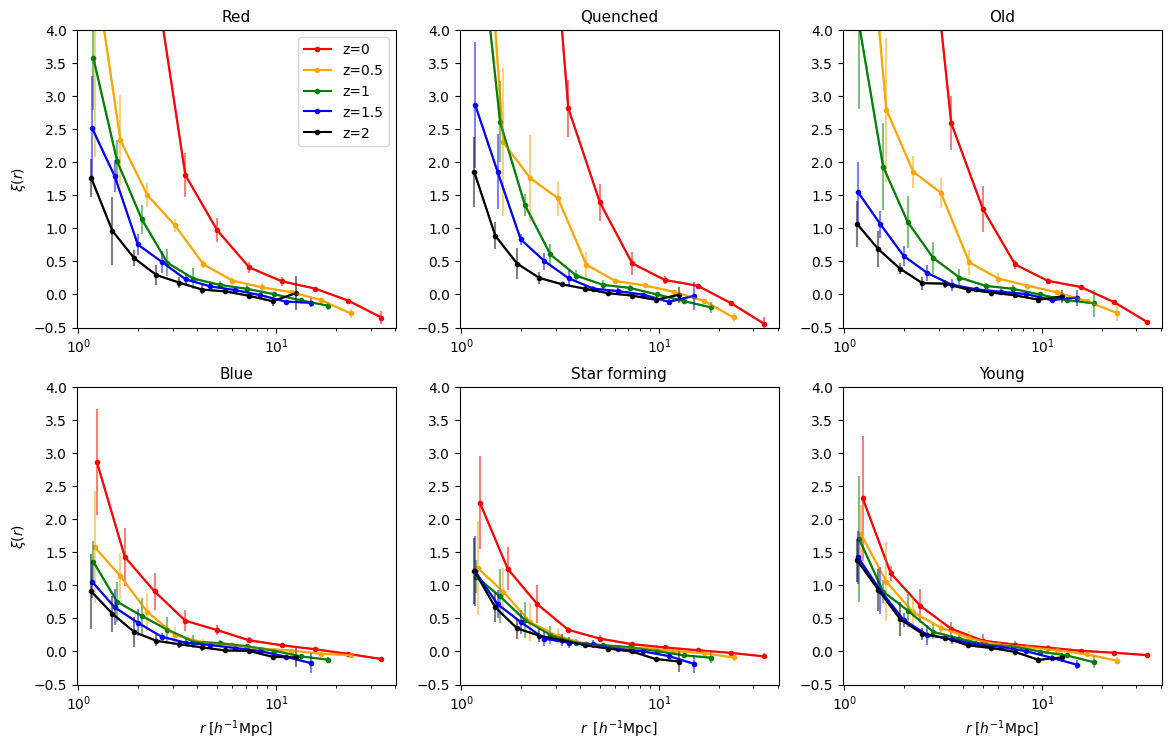

In [56]:
# plot
fig,ax = plt.subplots(2,3, figsize=(14, 8.5))

# red
ax[0][0].plot(red_0[0],red_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[0][0].errorbar(red_0[0], red_0[1],
        yerr=uncertain_red_0[1], color= 'Red', alpha = .5)
ax[0][0].plot(red_05[0], red_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[0][0].errorbar(red_05[0], red_05[1],
        yerr=uncertain_red_05[1], color= 'Orange', alpha = .5)
ax[0][0].plot(red_1[0],red_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[0][0].errorbar(red_1[0], red_1[1],
        yerr=uncertain_red_1[1], color= 'Green', alpha = .5)
ax[0][0].plot(red_15[0], red_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[0][0].errorbar(red_15[0], red_15[1],
        yerr=uncertain_red_15[1], color= 'Blue', alpha = .5)
ax[0][0].plot(red_2[0], red_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[0][0].errorbar(red_2[0], red_2[1],
        yerr=uncertain_red_2[1], color= 'Black', alpha = .5)
#ax[0][0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax[0][0].set_ylabel(r"$\xi (r)$")
ax[0][0].set_title('Red', fontsize=11)
ax[0][0].set_ylim(-0.5,4)
#ax[0][0].set_xlim(10e-1,10**(1.5))
ax[0][0].set_xscale('log')
ax[0][0].legend()

# blue
ax[1][0].plot(blue_0[0],blue_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[1][0].errorbar(blue_0[0], blue_0[1],
        yerr=uncertain_blue_0[1], color= 'Red', alpha = .5)
ax[1][0].plot(blue_05[0],blue_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[1][0].errorbar(blue_05[0], blue_05[1],
        yerr=uncertain_blue_05[1], color= 'Orange', alpha = .5)
ax[1][0].plot(blue_1[0],blue_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[1][0].errorbar(blue_1[0], blue_1[1],
        yerr=uncertain_blue_1[1], color= 'Green', alpha = .5)
ax[1][0].plot(blue_15[0], blue_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[1][0].errorbar(blue_15[0], blue_15[1],
        yerr=uncertain_blue_15[1], color= 'Blue', alpha = .5)
ax[1][0].plot(blue_2[0],blue_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[1][0].errorbar(blue_2[0], blue_2[1],
        yerr=uncertain_blue_2[1], color= 'Black', alpha = .5)
ax[1][0].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
ax[1][0].set_ylabel(r"$\xi (r)$")
ax[1][0].set_title('Blue', fontsize=11)
ax[1][0].set_ylim(-0.5,4)
#ax[1][0].set_xlim(10e-1,10**(1.5))
ax[1][0].set_xscale('log')
#ax[1][0].legend()

# quenched
ax[0][1].plot(quenched_0[0],quenched_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[0][1].errorbar(quenched_0[0], quenched_0[1],
        yerr=uncertain_quenched_0[1], color= 'Red', alpha = .5)
ax[0][1].plot(quenched_05[0],quenched_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[0][1].errorbar(quenched_05[0], quenched_05[1],
        yerr=uncertain_quenched_05[1], color= 'Orange', alpha = .5)
ax[0][1].plot(quenched_1[0],quenched_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[0][1].errorbar(quenched_1[0], quenched_1[1],
        yerr=uncertain_quenched_1[1], color= 'Green', alpha = .5)
ax[0][1].plot(quenched_15[0],quenched_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[0][1].errorbar(quenched_15[0], quenched_15[1],
        yerr=uncertain_quenched_15[1], color= 'Blue', alpha = .5)
ax[0][1].plot(quenched_2[0],quenched_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[0][1].errorbar(quenched_2[0], quenched_2[1],
        yerr=uncertain_quenched_2[1], color= 'Black', alpha = .5)
#ax[0][1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[0][1].set_ylabel(r"$w_{p} (r_{p})$")
ax[0][1].set_title('Quenched', fontsize=11)
ax[0][1].set_ylim(-0.5,4)
#ax[0][1].set_xlim(10e-1,10**(1.5))
ax[0][1].set_xscale('log')
#ax[0][1].legend()

# star forming
ax[1][1].plot(starform_0[0],starform_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[1][1].errorbar(starform_0[0], starform_0[1],
        yerr=uncertain_starform_0[1], color= 'Red', alpha = .5)
ax[1][1].plot(starform_05[0],starform_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[1][1].errorbar(starform_05[0], starform_05[1],
        yerr=uncertain_starform_05[1], color= 'Orange', alpha = .5)
ax[1][1].plot(starform_1[0],starform_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[1][1].errorbar(starform_1[0], starform_1[1],
        yerr=uncertain_starform_1[1], color= 'Green', alpha = .5)
ax[1][1].plot(starform_15[0],starform_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[1][1].errorbar(starform_15[0], starform_15[1],
        yerr=uncertain_starform_15[1], color= 'Blue', alpha = .5)
ax[1][1].plot(starform_2[0],starform_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[1][1].errorbar(starform_2[0], starform_2[1],
        yerr=uncertain_starform_2[1], color= 'Black', alpha = .5)
ax[1][1].set_xlabel(r"$r_ \; [h^{-1} \mathrm{Mpc}]$")
#ax[1][1].set_ylabel(r"$w_{p} (r_{p})$")
ax[1][1].set_title('Star forming', fontsize=11)
ax[1][1].set_ylim(-0.5,4)
#ax[1][1].set_xlim(10e-1,10**(1.5))
ax[1][1].set_xscale('log')
#ax[1][1].legend()

# old
ax[0][2].plot(old_0[0],old_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[0][2].errorbar(old_0[0], old_0[1],
        yerr=uncertain_old_0[1], color= 'Red', alpha = .5)
ax[0][2].plot(old_05[0],old_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[0][2].errorbar(old_05[0], old_05[1],
        yerr=uncertain_old_05[1], color= 'Orange', alpha = .5)
ax[0][2].plot(old_1[0],old_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[0][2].errorbar(old_1[0],old_1[1],
        yerr=uncertain_old_1[1], color= 'Green', alpha = .5)
ax[0][2].plot(old_15[0],old_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[0][2].errorbar(old_15[0], old_15[1],
        yerr=uncertain_old_15[1], color= 'Blue', alpha = .5)
ax[0][2].plot(old_2[0],old_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[0][2].errorbar(old_2[0], old_2[1],
        yerr=uncertain_old_2[1], color= 'Black', alpha = .5)
#ax[0][2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[0][2].set_ylabel(r"$w_{p} (r_{p})$")
ax[0][2].set_title('Old', fontsize=11)
ax[0][2].set_ylim(-0.5,4)
#ax[0][2].set_xlim(10e-1,10**(1.5))
ax[0][2].set_xscale('log')
#ax[0][2].legend()

# young
ax[1][2].plot(young_0[0],young_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[1][2].errorbar(young_0[0], young_0[1],
        yerr=uncertain_young_0[1], color= 'Red', alpha = .5)
ax[1][2].plot(young_05[0],young_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[1][2].errorbar(young_05[0], young_05[1],
        yerr=uncertain_young_05[1], color= 'Orange', alpha = .5)
ax[1][2].plot(young_1[0],young_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[1][2].errorbar(young_1[0], young_1[1],
        yerr=uncertain_young_1[1], color= 'Green', alpha = .5)
ax[1][2].plot(young_15[0],young_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[1][2].errorbar(young_15[0], young_15[1],
        yerr=uncertain_young_15[1], color= 'Blue', alpha = .5)
ax[1][2].plot(young_2[0],young_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[1][2].errorbar(young_2[0], young_2[1],
        yerr=uncertain_young_2[1], color= 'Black', alpha = .5)
ax[1][2].set_xlabel(r"$r \; [h^{-1} \mathrm{Mpc}]$")
#ax[1][2].set_ylabel(r"$w_{p} (r_{p})$")
ax[1][2].set_title('Young', fontsize=11)
ax[1][2].set_ylim(-0.5,4)
#ax[1][2].set_xlim(10e-1,10**(1.5))
ax[1][2].set_xscale('log');
#ax[1][2].legend();

#plt.tight_layout()

##### Projected correlation function

Color z = 0

In [57]:
# get the galaxies ordered by color
gal1_0 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_0.galaxies}
gal_sorted1_0 = sorted(gal1_0, key=gal1_0.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_0 = len(gal_sorted1_0)//4
less1_0 = gal_sorted1_0[:limit_0] #blue
more1_0 = gal_sorted1_0[-limit_0:] #red
print(len(gal_sorted1_0))
print(len(more1_0))
print(len(less1_0))

# calculate projected correlation function
pcf_red_0 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more1_0]),
    box_size= obj_0.simulation.boxsize,
    binnumber=10
)
pcf_blue_0 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less1_0]),
    box_size= obj_0.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_red_0 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more1_0]),
    size_box= obj_0.simulation.boxsize,
    number_bin= 10
)
uncertain_blue_0 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less1_0]),
    size_box= obj_0.simulation.boxsize,
    number_bin= 10
)

6922
1730
1730


Color z = 0.5

In [58]:
# get the galaxies ordered by color
gal1_05 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_05.galaxies}
gal_sorted1_05 = sorted(gal1_05, key=gal1_05.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_05 = len(gal_sorted1_05)//4
less1_05 = gal_sorted1_05[:limit_05] #blue
more1_05 = gal_sorted1_05[-limit_05:] #red
print(len(gal_sorted1_05))
print(len(more1_05))
print(len(less1_05))

# calculate projected correlation function
pcf_red_05 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more1_05]),
    box_size= obj_05.simulation.boxsize,
    binnumber=10
)
pcf_blue_05 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less1_05]),
    box_size= obj_05.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_red_05 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more1_05]),
    size_box= obj_05.simulation.boxsize,
    number_bin= 10
)
uncertain_blue_05 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less1_05]),
    size_box= obj_05.simulation.boxsize,
    number_bin= 10
)

5685
1421
1421


Color z = 1

In [59]:
# get the galaxies ordered by color
gal1_1 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_1.galaxies}
gal_sorted1_1 = sorted(gal1_1, key=gal1_1.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_1 = len(gal_sorted1_1)//4
less1_1 = gal_sorted1_1[:limit_1] #blue
more1_1 = gal_sorted1_1[-limit_1:] #red
print(len(gal_sorted1_1))
print(len(more1_1))
print(len(less1_1))

# calculate projected correlation function
pcf_red_1 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more1_1]),
    box_size= obj_1.simulation.boxsize,
    binnumber=10
)
pcf_blue_1 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less1_1]),
    box_size= obj_1.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_red_1 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more1_1]),
    size_box= obj_1.simulation.boxsize,
    number_bin= 10
)
uncertain_blue_1 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less1_1]),
    size_box= obj_1.simulation.boxsize,
    number_bin= 10
)

4931
1232
1232


/home/oni/master/functions.py:852: RuntimeWarning: divide by zero encountered in divide
  xi = np.divide(hist1,hist2)
/home/oni/miniconda3/envs/caesar_env/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Color z = 1.5

In [60]:
# get the galaxies ordered by color
gal1_15 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_15.galaxies}
gal_sorted1_15 = sorted(gal1_15, key=gal1_15.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_15 = len(gal_sorted1_15)//4
less1_15 = gal_sorted1_15[:limit_15] #blue
more1_15 = gal_sorted1_15[-limit_15:] #red
print(len(gal_sorted1_15))
print(len(more1_15))
print(len(less1_15))

# calculate projected correlation function
pcf_red_15 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more1_15]),
    box_size= obj_15.simulation.boxsize,
    binnumber=10
)
pcf_blue_15 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less1_15]),
    box_size= obj_15.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_red_15 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more1_15]),
    size_box= obj_15.simulation.boxsize,
    number_bin= 10
)
uncertain_blue_15 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less1_15]),
    size_box= obj_15.simulation.boxsize,
    number_bin= 10
)

4345
1086
1086


Color z = 2

In [61]:
# get the galaxies ordered by color
gal1_2 = {i: i.absmag["lsst_r"] - i.absmag["lsst_i"] for i in obj_2.galaxies}
gal_sorted1_2 = sorted(gal1_2, key=gal1_2.get)

# get the bottom and top 25% ordered by color.
# create two samples (blue and red galaxies) 
limit_2 = len(gal_sorted1_2)//4
less1_2 = gal_sorted1_1[:limit_2] #blue
more1_2 = gal_sorted1_1[-limit_2:] #red
print(len(gal_sorted1_2))
print(len(more1_2))
print(len(less1_2))

# calculate projected correlation function
pcf_red_2 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more1_2]),
    box_size= obj_2.simulation.boxsize,
    binnumber=10
)
pcf_blue_2 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less1_2]),
    box_size= obj_2.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_red_2 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more1_2]),
    size_box= obj_2.simulation.boxsize,
    number_bin= 10
)
uncertain_blue_2 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less1_2]),
    size_box= obj_2.simulation.boxsize,
    number_bin= 10
)

3814
953
953


sSFR z = 0

In [62]:
# get the galaxies ordered by sSFR
gal2_0 = {i: i.sfr / i.masses["stellar"] for i in obj_0.galaxies}
gal_sorted2_0 = sorted(gal2_0, key=gal2_0.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_0 = len(gal_sorted2_0)//4
less2_0 = gal_sorted2_0[:limit_0] #quenched
more2_0 = gal_sorted2_0[-limit_0:] #star forming
print(len(gal_sorted2_0))
print(len(more2_0))
print(len(less2_0))

# calculate projected correlation function
pcf_starform_0 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more2_0]),
    box_size= obj_0.simulation.boxsize,
    binnumber=10
)
pcf_quenched_0 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less2_0]),
    box_size= obj_0.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_starform_0 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more2_0]),
    size_box= obj_0.simulation.boxsize,
    number_bin= 10
)
uncertain_quenched_0 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less2_0]),
    size_box= obj_0.simulation.boxsize,
    number_bin= 10
)

6922
1730
1730


sSFR z = 0.5

In [63]:
# get the galaxies ordered by sSFR
gal2_05 = {i: i.sfr / i.masses["stellar"] for i in obj_05.galaxies}
gal_sorted2_05 = sorted(gal2_05, key=gal2_05.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_05 = len(gal_sorted2_05)//4
less2_05 = gal_sorted2_05[:limit_05] #quenched
more2_05 = gal_sorted2_05[-limit_05:] #star forming
print(len(gal_sorted2_05))
print(len(more2_05))
print(len(less2_05))

# calculate projected correlation function
pcf_starform_05 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more2_05]),
    box_size= obj_05.simulation.boxsize,
    binnumber=10
)
pcf_quenched_05 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less2_05]),
    box_size= obj_05.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_starform_05 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more2_05]),
    size_box= obj_05.simulation.boxsize,
    number_bin= 10
)
uncertain_quenched_05 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less2_05]),
    size_box= obj_05.simulation.boxsize,
    number_bin= 10
)

5685
1421
1421


sSFR z = 1

In [64]:
# get the galaxies ordered by sSFR
gal2_1 = {i: i.sfr / i.masses["stellar"] for i in obj_1.galaxies}
gal_sorted2_1 = sorted(gal2_1, key=gal2_1.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_1 = len(gal_sorted2_1)//4
less2_1 = gal_sorted2_1[:limit_1] #quenched
more2_1 = gal_sorted2_1[-limit_1:] #star forming
print(len(gal_sorted2_1))
print(len(more2_1))
print(len(less2_1))

# calculate projected correlation function
pcf_starform_1 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more2_1]),
    box_size= obj_1.simulation.boxsize,
    binnumber=10
)
pcf_quenched_1 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less2_1]),
    box_size= obj_1.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_starform_1 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more2_1]),
    size_box= obj_1.simulation.boxsize,
    number_bin= 10
)
uncertain_quenched_1 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less2_1]),
    size_box= obj_1.simulation.boxsize,
    number_bin= 10
)

4931
1232
1232


sSFR z =1.5

In [65]:
# get the galaxies ordered by sSFR
gal2_15 = {i: i.sfr / i.masses["stellar"] for i in obj_15.galaxies}
gal_sorted2_15 = sorted(gal2_15, key=gal2_15.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_15 = len(gal_sorted2_15)//4
less2_15 = gal_sorted2_15[:limit_15] #quenched
more2_15 = gal_sorted2_15[-limit_15:] #star forming
print(len(gal_sorted2_15))
print(len(more2_15))
print(len(less2_15))

# calculate projected correlation function
pcf_starform_15 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more2_15]),
    box_size= obj_15.simulation.boxsize,
    binnumber=10
)
pcf_quenched_15 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less2_15]),
    box_size= obj_15.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_starform_15 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more2_15]),
    size_box= obj_15.simulation.boxsize,
    number_bin= 10
)
uncertain_quenched_15 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less2_15]),
    size_box= obj_15.simulation.boxsize,
    number_bin= 10
)

4345
1086
1086


sSFR z = 2

In [66]:
# get the galaxies ordered by sSFR
gal2_2 = {i: i.sfr / i.masses["stellar"] for i in obj_2.galaxies}
gal_sorted2_2 = sorted(gal2_2, key=gal2_2.get)

# get the bottom and top 25% ordered by sSFR.
# create two samples (star forming and quenched galaxies) 
limit_2 = len(gal_sorted2_2)//4
less2_2 = gal_sorted2_2[:limit_2] #quenched
more2_2 = gal_sorted2_2[-limit_2:] #star forming
print(len(gal_sorted2_2))
print(len(more2_2))
print(len(less2_2))

# calculate projected correlation function
pcf_starform_2 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more2_2]),
    box_size= obj_2.simulation.boxsize,
    binnumber=10
)
pcf_quenched_2 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less2_2]),
    box_size= obj_2.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_starform_2 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more2_2]),
    size_box= obj_2.simulation.boxsize,
    number_bin= 10
)
uncertain_quenched_2 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less2_2]),
    size_box= obj_2.simulation.boxsize,
    number_bin= 10
)

3814
953
953


Age z = 0

In [67]:
# get the galaxies ordered by age
gal3_0 = {i: i.ages["mass_weighted"] for i in obj_0.galaxies}
gal_sorted3_0 = sorted(gal3_0, key=gal3_0.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_0 = len(gal_sorted3_0)//4
less3_0 = gal_sorted3_0[:limit_0] #young
more3_0 = gal_sorted3_0[-limit_0:] #old
print(len(gal_sorted3_0))
print(len(more3_0))
print(len(less3_0))

# calculate projected correlation function
pcf_old_0 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more3_0]),
    box_size= obj_0.simulation.boxsize,
    binnumber=10
)
pcf_young_0 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less3_0]),
    box_size= obj_0.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_old_0 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more3_0]),
    size_box= obj_0.simulation.boxsize,
    number_bin= 10
)
uncertain_young_0 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less3_0]),
    size_box= obj_0.simulation.boxsize,
    number_bin= 10
)

6922
1730
1730


Age z = 0.5

In [68]:
# get the galaxies ordered by age
gal3_05 = {i: i.ages["mass_weighted"] for i in obj_05.galaxies}
gal_sorted3_05 = sorted(gal3_05, key=gal3_05.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_05 = len(gal_sorted3_05)//4
less3_05 = gal_sorted3_05[:limit_05] #young
more3_05 = gal_sorted3_05[-limit_05:] #old
print(len(gal_sorted3_05))
print(len(more3_05))
print(len(less3_05))

# calculate projected correlation function
pcf_old_05 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more3_05]),
    box_size= obj_05.simulation.boxsize,
    binnumber=10
)
pcf_young_05 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less3_05]),
    box_size= obj_05.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_old_05 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more3_05]),
    size_box= obj_05.simulation.boxsize,
    number_bin= 10
)
uncertain_young_05 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less3_05]),
    size_box= obj_05.simulation.boxsize,
    number_bin= 10
)

5685
1421
1421


Age z = 1

In [69]:
# get the galaxies ordered by age
gal3_1 = {i: i.ages["mass_weighted"] for i in obj_1.galaxies}
gal_sorted3_1 = sorted(gal3_1, key=gal3_1.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_1 = len(gal_sorted3_1)//4
less3_1 = gal_sorted3_1[:limit_1] #young
more3_1 = gal_sorted3_1[-limit_1:] #old
print(len(gal_sorted3_1))
print(len(more3_1))
print(len(less3_1))

# calculate projected correlation function
pcf_old_1 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more3_1]),
    box_size= obj_1.simulation.boxsize,
    binnumber=10
)
pcf_young_1 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less3_1]),
    box_size= obj_1.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_old_1 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more3_1]),
    size_box= obj_1.simulation.boxsize,
    number_bin= 10
)
uncertain_young_1 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less3_1]),
    size_box= obj_1.simulation.boxsize,
    number_bin= 10
)

4931
1232
1232


Age z = 1.5

In [70]:
# get the galaxies ordered by age
gal3_15 = {i: i.ages["mass_weighted"] for i in obj_15.galaxies}
gal_sorted3_15 = sorted(gal3_15, key=gal3_15.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_15 = len(gal_sorted3_15)//4
less3_15 = gal_sorted3_15[:limit_15] #young
more3_15 = gal_sorted3_15[-limit_15:] #old
print(len(gal_sorted3_15))
print(len(more3_15))
print(len(less3_15))

# calculate projected correlation function
pcf_old_15 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more3_15]),
    box_size= obj_15.simulation.boxsize,
    binnumber=10
)
pcf_young_15 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less3_15]),
    box_size= obj_15.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_old_15 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more3_15]),
    size_box= obj_15.simulation.boxsize,
    number_bin= 10
)
uncertain_young_15 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less3_15]),
    size_box= obj_15.simulation.boxsize,
    number_bin= 10
)

4345
1086
1086


Age z = 2

In [71]:
# get the galaxies ordered by age
gal3_2 = {i: i.ages["mass_weighted"] for i in obj_2.galaxies}
gal_sorted3_2 = sorted(gal3_2, key=gal3_2.get)

# get the bottom and top 25% ordered by age.
# create two samples (old and young galaxies) 
limit_2 = len(gal_sorted3_2)//4
less3_2 = gal_sorted3_2[:limit_2] #young
more3_2 = gal_sorted3_2[-limit_2:] #old
print(len(gal_sorted3_2))
print(len(more3_2))
print(len(less3_2))

# calculate projected correlation function
pcf_old_2 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in more3_2]),
    box_size= obj_2.simulation.boxsize,
    binnumber=10
)
pcf_young_2 = calculate_projected_2pcf(
    data= np.array([i.pos.to(unit) for i in less3_2]),
    box_size= obj_2.simulation.boxsize,
    binnumber=10
)

# estimate the uncertainty using k-fold
uncertain_old_2 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in more3_2]),
    size_box= obj_2.simulation.boxsize,
    number_bin= 10
)
uncertain_young_2 = find_ptpcf_uncertainty_kfold(
    positions= np.array([i.pos.to(unit) for i in less3_2]),
    size_box= obj_2.simulation.boxsize,
    number_bin= 10
)

3814
953
953


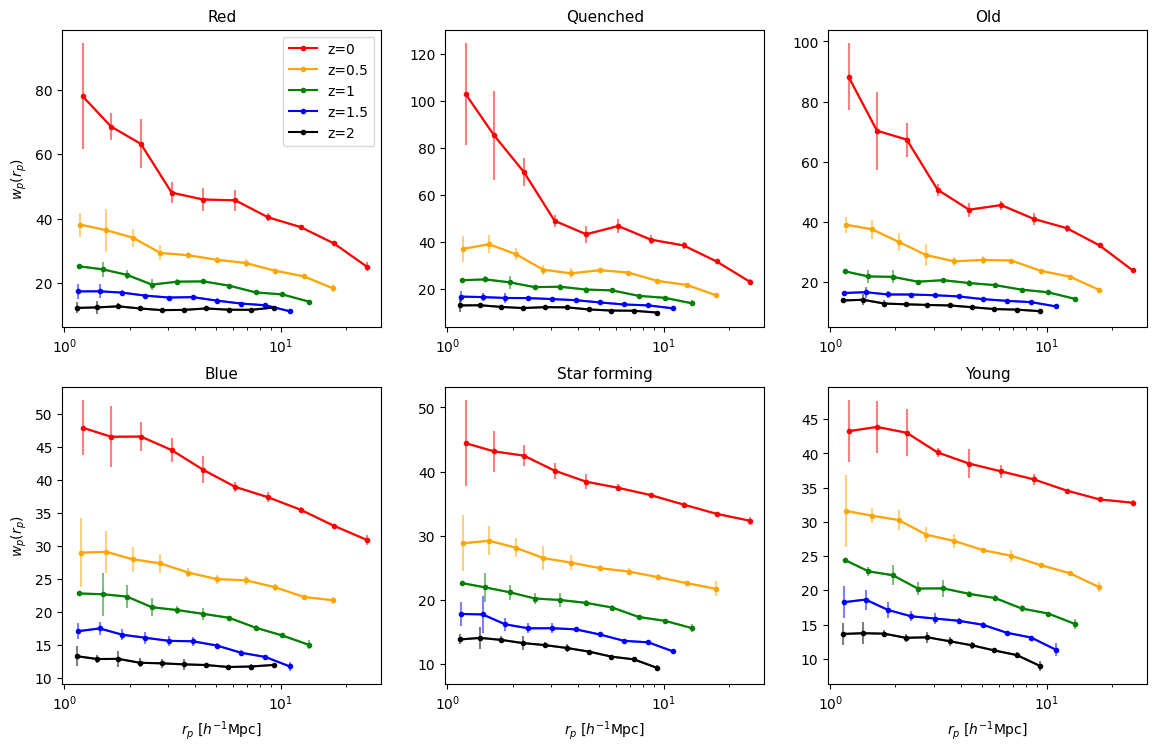

In [50]:
# plot
fig,ax = plt.subplots(2,3, figsize=(14, 8.5))

# red
ax[0][0].plot(pcf_red_0[0],pcf_red_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[0][0].errorbar(pcf_red_0[0], pcf_red_0[1],
        yerr=uncertain_red_0[1], color= 'Red', alpha = .5)
ax[0][0].plot(pcf_red_05[0],pcf_red_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[0][0].errorbar(pcf_red_05[0], pcf_red_05[1],
        yerr=uncertain_red_05[1], color= 'Orange', alpha = .5)
ax[0][0].plot(pcf_red_1[0],pcf_red_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[0][0].errorbar(pcf_red_1[0], pcf_red_1[1],
        yerr=uncertain_red_1[1], color= 'Green', alpha = .5)
ax[0][0].plot(pcf_red_15[0],pcf_red_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[0][0].errorbar(pcf_red_15[0], pcf_red_15[1],
        yerr=uncertain_red_15[1], color= 'Blue', alpha = .5)
ax[0][0].plot(pcf_red_2[0],pcf_red_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[0][0].errorbar(pcf_red_2[0], pcf_red_2[1],
        yerr=uncertain_red_2[1], color= 'Black', alpha = .5)
#ax[0][0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax[0][0].set_ylabel(r"$w_{p} (r_{p})$")
ax[0][0].set_title('Red', fontsize=11)
#ax[0][0].set_ylim(0,2.5)
#ax[0][0].set_xlim(10e-1,10**(1.5))
ax[0][0].set_xscale('log')
ax[0][0].legend()

# blue
ax[1][0].plot(pcf_blue_0[0],pcf_blue_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[1][0].errorbar(pcf_blue_0[0], pcf_blue_0[1],
        yerr=uncertain_blue_0[1], color= 'Red', alpha = .5)
ax[1][0].plot(pcf_blue_05[0],pcf_blue_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[1][0].errorbar(pcf_blue_05[0], pcf_blue_05[1],
        yerr=uncertain_blue_05[1], color= 'Orange', alpha = .5)
ax[1][0].plot(pcf_blue_1[0],pcf_blue_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[1][0].errorbar(pcf_blue_1[0], pcf_blue_1[1],
        yerr=uncertain_blue_1[1], color= 'Green', alpha = .5)
ax[1][0].plot(pcf_blue_15[0],pcf_blue_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[1][0].errorbar(pcf_blue_15[0], pcf_blue_15[1],
        yerr=uncertain_blue_15[1], color= 'Blue', alpha = .5)
ax[1][0].plot(pcf_blue_2[0],pcf_blue_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[1][0].errorbar(pcf_blue_2[0], pcf_blue_2[1],
        yerr=uncertain_blue_2[1], color= 'Black', alpha = .5)
ax[1][0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
ax[1][0].set_ylabel(r"$w_{p} (r_{p})$")
ax[1][0].set_title('Blue', fontsize=11)
#ax[1][0].set_ylim(0,2.5)
#ax[1][0].set_xlim(10e-1,10**(1.5))
ax[1][0].set_xscale('log')
#ax[1][0].legend()

# quenched
ax[0][1].plot(pcf_quenched_0[0],pcf_quenched_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[0][1].errorbar(pcf_quenched_0[0], pcf_quenched_0[1],
        yerr=uncertain_quenched_0[1], color= 'Red', alpha = .5)
ax[0][1].plot(pcf_quenched_05[0],pcf_quenched_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[0][1].errorbar(pcf_quenched_05[0], pcf_quenched_05[1],
        yerr=uncertain_quenched_05[1], color= 'Orange', alpha = .5)
ax[0][1].plot(pcf_quenched_1[0],pcf_quenched_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[0][1].errorbar(pcf_quenched_1[0], pcf_quenched_1[1],
        yerr=uncertain_quenched_1[1], color= 'Green', alpha = .5)
ax[0][1].plot(pcf_quenched_15[0],pcf_quenched_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[0][1].errorbar(pcf_quenched_15[0], pcf_quenched_15[1],
        yerr=uncertain_quenched_15[1], color= 'Blue', alpha = .5)
ax[0][1].plot(pcf_quenched_2[0],pcf_quenched_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[0][1].errorbar(pcf_quenched_2[0], pcf_quenched_2[1],
        yerr=uncertain_quenched_2[1], color= 'Black', alpha = .5)
#ax[0][1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[0][1].set_ylabel(r"$w_{p} (r_{p})$")
ax[0][1].set_title('Quenched', fontsize=11)
#ax[0][1].set_ylim(0,2.5)
#ax[0][1].set_xlim(10e-1,10**(1.5))
ax[0][1].set_xscale('log')
#ax[0][1].legend()

# star forming
ax[1][1].plot(pcf_starform_0[0],pcf_starform_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[1][1].errorbar(pcf_starform_0[0], pcf_starform_0[1],
        yerr=uncertain_starform_0[1], color= 'Red', alpha = .5)
ax[1][1].plot(pcf_starform_05[0],pcf_starform_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[1][1].errorbar(pcf_starform_05[0], pcf_starform_05[1],
        yerr=uncertain_starform_05[1], color= 'Orange', alpha = .5)
ax[1][1].plot(pcf_starform_1[0],pcf_starform_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[1][1].errorbar(pcf_starform_1[0], pcf_starform_1[1],
        yerr=uncertain_starform_1[1], color= 'Green', alpha = .5)
ax[1][1].plot(pcf_starform_15[0],pcf_starform_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[1][1].errorbar(pcf_starform_15[0], pcf_starform_15[1],
        yerr=uncertain_starform_15[1], color= 'Blue', alpha = .5)
ax[1][1].plot(pcf_starform_2[0],pcf_starform_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[1][1].errorbar(pcf_starform_2[0], pcf_starform_2[1],
        yerr=uncertain_starform_2[1], color= 'Black', alpha = .5)
ax[1][1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[1][1].set_ylabel(r"$w_{p} (r_{p})$")
ax[1][1].set_title('Star forming', fontsize=11)
#ax[1][1].set_ylim(0,2.5)
#ax[1][1].set_xlim(10e-1,10**(1.5))
ax[1][1].set_xscale('log')
#ax[1][1].legend()

# old
ax[0][2].plot(pcf_old_0[0],pcf_old_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[0][2].errorbar(pcf_old_0[0], pcf_old_0[1],
        yerr=uncertain_old_0[1], color= 'Red', alpha = .5)
ax[0][2].plot(pcf_old_05[0],pcf_old_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[0][2].errorbar(pcf_old_05[0], pcf_old_05[1],
        yerr=uncertain_old_05[1], color= 'Orange', alpha = .5)
ax[0][2].plot(pcf_old_1[0],pcf_old_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[0][2].errorbar(pcf_old_1[0], pcf_old_1[1],
        yerr=uncertain_old_1[1], color= 'Green', alpha = .5)
ax[0][2].plot(pcf_old_15[0],pcf_old_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[0][2].errorbar(pcf_old_15[0], pcf_old_15[1],
        yerr=uncertain_old_15[1], color= 'Blue', alpha = .5)
ax[0][2].plot(pcf_old_2[0],pcf_old_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[0][2].errorbar(pcf_old_2[0], pcf_old_2[1],
        yerr=uncertain_old_2[1], color= 'Black', alpha = .5)
#ax[0][2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[0][2].set_ylabel(r"$w_{p} (r_{p})$")
ax[0][2].set_title('Old', fontsize=11)
#ax[0][2].set_ylim(0,2.5)
#ax[0][2].set_xlim(10e-1,10**(1.5))
ax[0][2].set_xscale('log')
#ax[0][2].legend()

# young
ax[1][2].plot(pcf_young_0[0],pcf_young_0[1], marker = '.',
        color= 'Red', label = 'z=0')
ax[1][2].errorbar(pcf_young_0[0], pcf_young_0[1],
        yerr=uncertain_young_0[1], color= 'Red', alpha = .5)
ax[1][2].plot(pcf_young_05[0],pcf_young_05[1], marker = '.',
        color= 'Orange', label = 'z=0.5')
ax[1][2].errorbar(pcf_young_05[0], pcf_young_05[1],
        yerr=uncertain_young_05[1], color= 'Orange', alpha = .5)
ax[1][2].plot(pcf_young_1[0],pcf_young_1[1], marker = '.',
        color= 'Green', label = 'z=1')
ax[1][2].errorbar(pcf_young_1[0], pcf_young_1[1],
        yerr=uncertain_young_1[1], color= 'Green', alpha = .5)
ax[1][2].plot(pcf_young_15[0],pcf_young_15[1], marker = '.',
        color= 'Blue', label = 'z=1.5')
ax[1][2].errorbar(pcf_young_15[0], pcf_young_15[1],
        yerr=uncertain_young_15[1], color= 'Blue', alpha = .5)
ax[1][2].plot(pcf_young_2[0],pcf_young_2[1], marker = '.',
        color= 'Black', label = 'z=2')
ax[1][2].errorbar(pcf_young_2[0], pcf_young_2[1],
        yerr=uncertain_young_2[1], color= 'Black', alpha = .5)
ax[1][2].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$")
#ax[1][2].set_ylabel(r"$w_{p} (r_{p})$")
ax[1][2].set_title('Young', fontsize=11)
#ax[1][2].set_ylim(0,2.5)
#ax[1][2].set_xlim(10e-1,10**(1.5))
ax[1][2].set_xscale('log');
#ax[1][2].legend();

#plt.tight_layout()